In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

anime_df = pd.read_csv('data/AnimeList/AnimeList.csv')
print(anime_df.isnull().sum())

anime_id              0
title                 0
title_english      8754
title_japanese       35
title_synonyms     5541
image_url            96
type                  0
source                0
episodes              0
status                0
airing                0
aired_string          0
aired                 0
duration              0
rating              544
score                 0
scored_by             0
rank               1574
popularity            0
members               0
favorites             0
background        13421
premiered         10382
broadcast         10207
related               0
producer           6190
licensor          11105
studio             5934
genre                64
opening_theme         0
ending_theme          0
dtype: int64


In [3]:
anime_df = anime_df.dropna(subset = ['genre', 'rating', 'image_url','title_japanese'])
anime_df['title_english'] = anime_df['title_english'].fillna(anime_df['title'])
anime_df['title_synonyms'] = anime_df['title_synonyms'].fillna(anime_df['title'])
anime_df = anime_df[(anime_df['rank'].notnull()) & (anime_df['members'] > 1000)]
anime_df['studio'] = anime_df['studio'].fillna('Unknown')
anime_df = anime_df.drop(columns=['licensor', 'producer', 'background', 'premiered', 'broadcast'])


In [4]:
print(anime_df.isnull().sum())

anime_id          0
title             0
title_english     0
title_japanese    0
title_synonyms    0
image_url         0
type              0
source            0
episodes          0
status            0
airing            0
aired_string      0
aired             0
duration          0
rating            0
score             0
scored_by         0
rank              0
popularity        0
members           0
favorites         0
related           0
studio            0
genre             0
opening_theme     0
ending_theme      0
dtype: int64


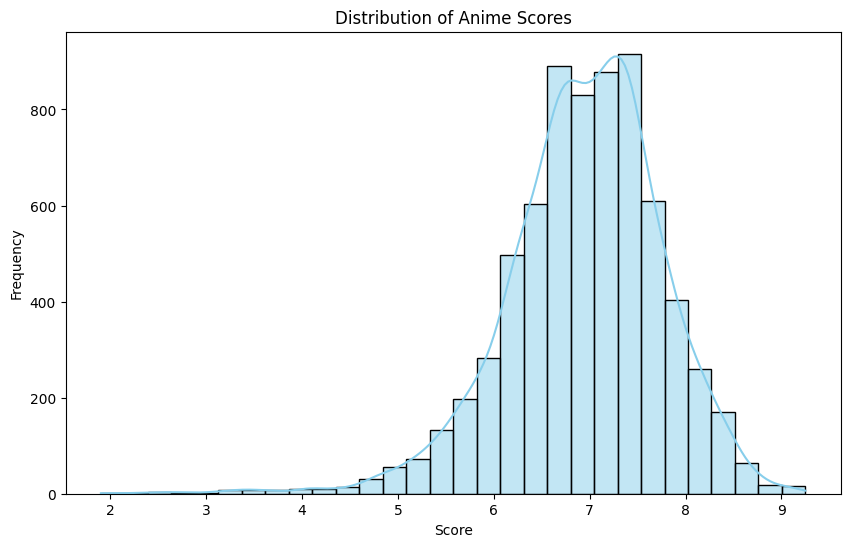

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(anime_df['score'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Anime Scores')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

C:\Users\brath\AppData\Local\Temp\ipykernel_4860\3327929433.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=all_genres, order=all_genres.value_counts().index, palette='viridis')


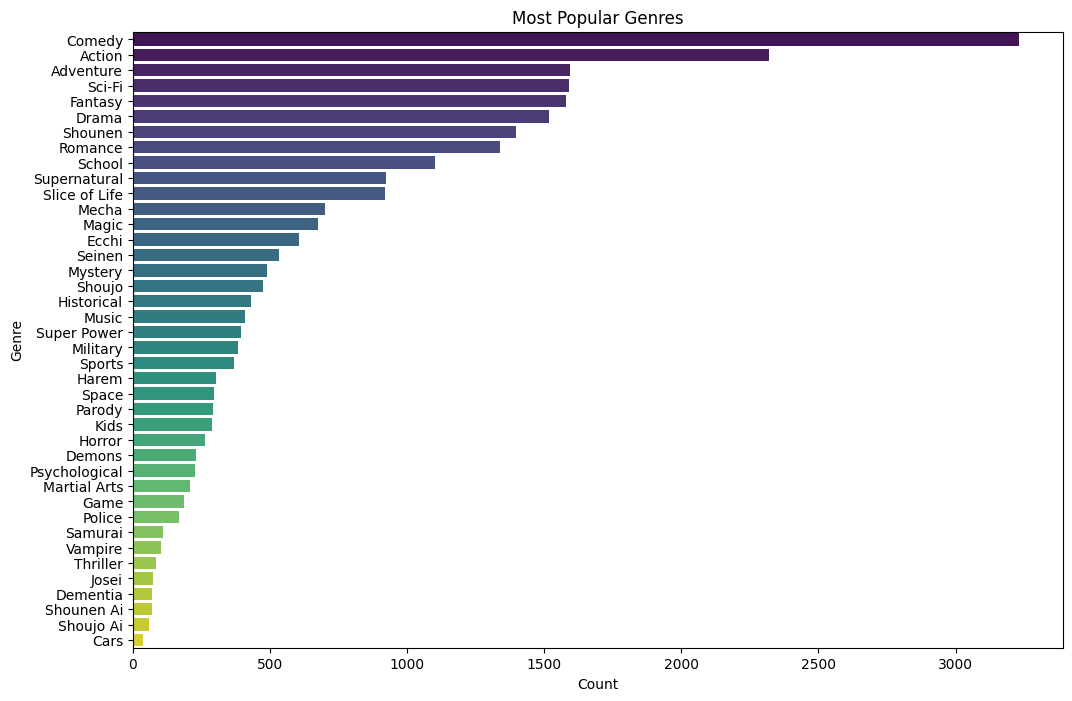

In [6]:
all_genres = anime_df['genre'].str.split(', ').explode()

plt.figure(figsize=(12, 8))
sns.countplot(y=all_genres, order=all_genres.value_counts().index, palette='viridis')
plt.title('Most Popular Genres')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

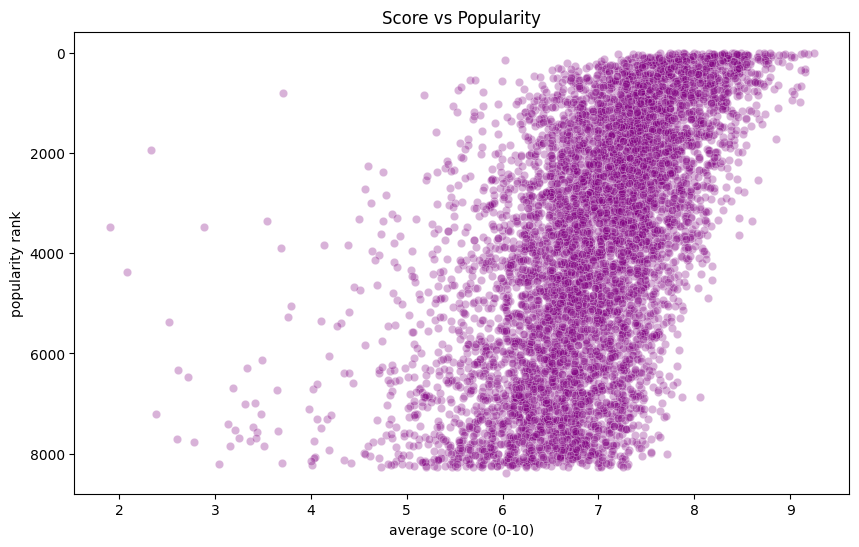

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=anime_df, x='score', y='popularity', alpha=0.3, color='purple')
plt.gca().invert_yaxis()
plt.title('Score vs Popularity')
plt.xlabel('average score (0-10)')
plt.ylabel('popularity rank')
plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# After cleaning the data the index still remain the same, we reset the index 
anime_df = anime_df.reset_index(drop=True)

tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(anime_df['genre'])
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

indices = pd.Series(anime_df.index, index=anime_df['title']).drop_duplicates()


In [ ]:
def get_recommendations(title, n=5):
    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    top_50 = sim_scores[1:51]
    
    top_indices = [i[0] for i in top_50]
    results = anime_df.iloc[top_indices].copy()
    temp_sim = [i[1] for i in top_50]
    results['similarity_percentage'] = temp_sim
    results['final_score'] = (results['similarity_percentage'] * 0.7) + (results['score'] / 10 * 0.3)
    
    return results.sort_values(by='final_score', ascending=False)[['title', 'score', 'genre', 'similarity_percentage']].head(n)

print(get_recommendations('Naruto'))


                                           title  score  \
2314                                      Naruto   7.88   
505                                Dragon Ball Z   8.31   
6136  Naruto: Shippuuden Movie 6 - Road to Ninja   7.82   
1871                      Dragon Ball Kai (2014)   7.92   
4038                             Dragon Ball Kai   7.91   

                                                  genre  similarity_percentage  
2314  Action, Adventure, Comedy, Super Power, Martia...               1.000000  
505   Action, Adventure, Comedy, Fantasy, Martial Ar...               0.967633  
6136  Action, Super Power, Adventure, Martial Arts, ...               0.982598  
1871  Action, Adventure, Comedy, Fantasy, Martial Ar...               0.967633  
4038  Action, Adventure, Comedy, Fantasy, Martial Ar...               0.967633  
